<a href="https://colab.research.google.com/github/yarolava/mn/blob/labwork/lab_3_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab_2: Using simple classification methods for solving classification problem
# Ярослава Наталіна
# КС31
# Task:
1. Do data preprocessing & data visualization as it was in the 1st lab work
2. Solve classification problem for the selected dataset.
3. Use `examples/fisher_irises.ipynb` as baseline for your experiments
4. Try to optimize hyperparameters of some model

# Datasets for classification

 [CS:GO Round Winner Classification](https://www.kaggle.com/datasets/christianlillelund/csgo-round-winner-classification)


In [1]:
import pandas as pd
df = pd.read_csv("csgo_round_snapshots.csv")

print(df.head())

   time_left  ct_score  t_score       map  bomb_planted  ct_health  t_health  \
0     175.00       0.0      0.0  de_dust2         False      500.0     500.0   
1     156.03       0.0      0.0  de_dust2         False      500.0     500.0   
2      96.03       0.0      0.0  de_dust2         False      391.0     400.0   
3      76.03       0.0      0.0  de_dust2         False      391.0     400.0   
4     174.97       1.0      0.0  de_dust2         False      500.0     500.0   

   ct_armor  t_armor  ct_money  ...  t_grenade_flashbang  \
0       0.0      0.0    4000.0  ...                  0.0   
1     400.0    300.0     600.0  ...                  0.0   
2     294.0    200.0     750.0  ...                  0.0   
3     294.0    200.0     750.0  ...                  0.0   
4     192.0      0.0   18350.0  ...                  0.0   

   ct_grenade_smokegrenade  t_grenade_smokegrenade  \
0                      0.0                     0.0   
1                      0.0                     2.0

In [2]:
print("Пропущені значення:\n", df.isnull().sum())




Пропущені значення:
 time_left                    0
ct_score                     0
t_score                      0
map                          0
bomb_planted                 0
                            ..
ct_grenade_molotovgrenade    0
t_grenade_molotovgrenade     0
ct_grenade_decoygrenade      0
t_grenade_decoygrenade       0
round_winner                 0
Length: 97, dtype: int64


In [6]:
if 'bomb_planted' in df.columns:
    df['bomb_planted'] = df['bomb_planted'].astype(int)

df['win_team'] = df['round_winner'].map({'CT': 0, 'T': 1})

columns_to_drop = ['map', 'round_winner', 'round', 'time_left']
existing_columns = [col for col in columns_to_drop if col in df.columns]
df.drop(columns=existing_columns, inplace=True)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122410 entries, 0 to 122409
Data columns (total 95 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   ct_score                      122410 non-null  float64
 1   t_score                       122410 non-null  float64
 2   bomb_planted                  122410 non-null  int64  
 3   ct_health                     122410 non-null  float64
 4   t_health                      122410 non-null  float64
 5   ct_armor                      122410 non-null  float64
 6   t_armor                       122410 non-null  float64
 7   ct_money                      122410 non-null  float64
 8   t_money                       122410 non-null  float64
 9   ct_helmets                    122410 non-null  float64
 10  t_helmets                     122410 non-null  float64
 11  ct_defuse_kits                122410 non-null  float64
 12  ct_players_alive              122410 non-nul

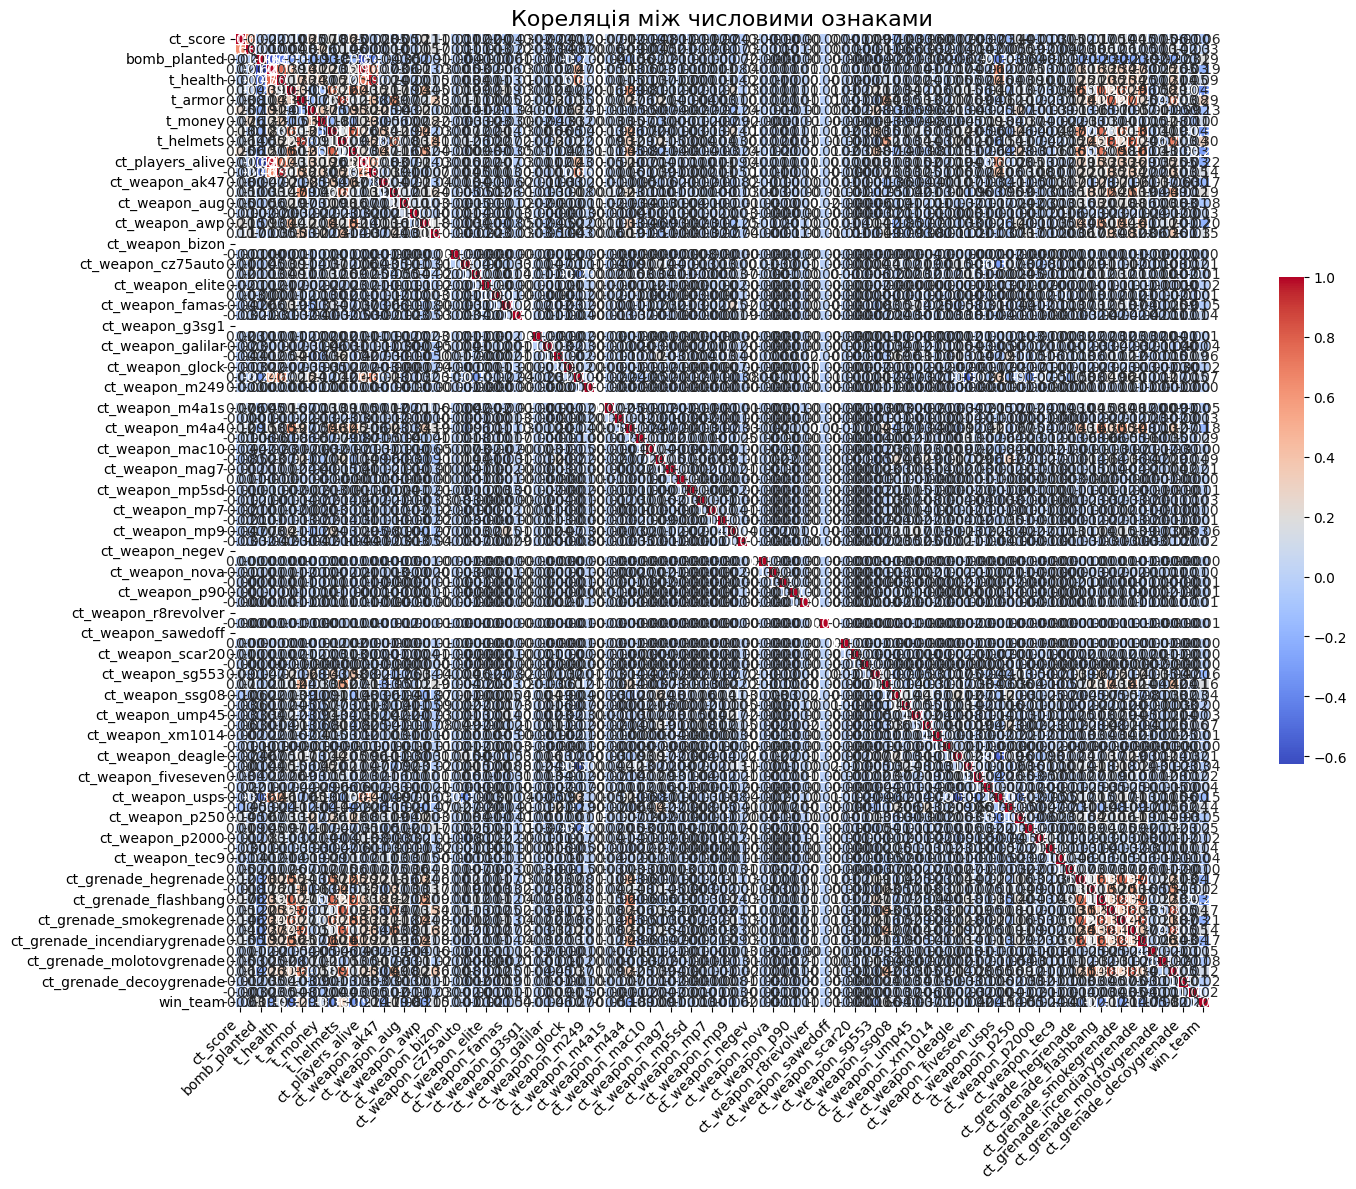

In [15]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(),
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            square=True,
            linewidths=.5,
            cbar_kws={"shrink": .5})

plt.title("Кореляція між числовими ознаками", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



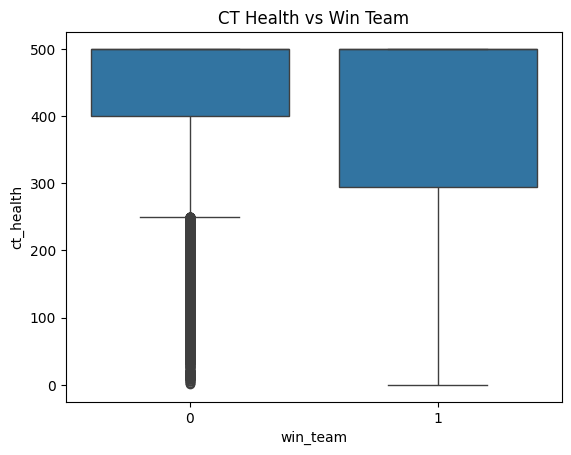

In [11]:
# Boxplot: ознака vs win_team
sns.boxplot(x='win_team', y='ct_health', data=df)
plt.title("CT Health vs Win Team")
plt.show()


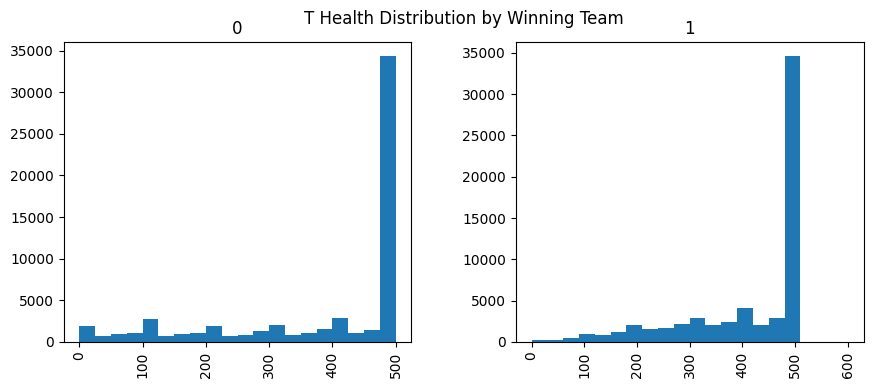

In [12]:

# Histogram
df['t_health'].hist(by=df['win_team'], figsize=(10,4), bins=20)
plt.suptitle("T Health Distribution by Winning Team")
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Виділяємо X і y
X = df.drop('win_team', axis=1)
y = df['win_team']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Модель
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Прогноз
y_pred = model.predict(X_test)

# Результати
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8789723061841352
Confusion matrix:
 [[10693  1311]
 [ 1652 10826]]
Classification report:
               precision    recall  f1-score   support

           0       0.87      0.89      0.88     12004
           1       0.89      0.87      0.88     12478

    accuracy                           0.88     24482
   macro avg       0.88      0.88      0.88     24482
weighted avg       0.88      0.88      0.88     24482



In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Зменшуємо обсяг тренувальних даних
X_sample = X_train.sample(frac=0.3, random_state=42)
y_sample = y_train.loc[X_sample.index]

# Параметри для перебору
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

# GridSearch на меншій вибірці
grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    cv=3,
                    scoring='accuracy')

grid.fit(X_sample, y_sample)  # ← ТЕПЕР ПРАВИЛЬНО

print("Найкращі параметри:", grid.best_params_)
print("Точність з ними:", grid.best_score_)


Найкращі параметри: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Точність з ними: 0.759684006733501


In [19]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)
print("Точність на тесті:", model.score(X_test, y_test))


Точність на тесті: 0.7593333877951148
